EXPLORATORY DATA ANALYSIS: ANTOINE DUPONT

BASIC PROFILE
Name: Antoine Dupont
Nationality: France
Position: Scrumhalf
Age: 27 | Height: 1.74m | Weight: 86kg
Club: Toulouse

DETAILED PERFORMANCE ANALYSIS

📊 CLUB TOURNAMENT PERFORMANCE:
  • Matches: 14 (77.6th percentile)
  • Wins: 11 (91.8th percentile)
  • Tries: 6 (91.3th percentile)
  • Points: 30 (78.1th percentile)
  • Minutes: 866 (66.0th percentile)

📊 OTHER COMPETITION PERFORMANCE:
  • Matches: 8 (93.8th percentile)
  • Wins: 8 (97.9th percentile)
  • Tries: 5 (96.9th percentile)
  • Points: 25 (88.7th percentile)
  • Minutes: 627 (99.0th percentile)

📊 NATIONAL TEAM PERFORMANCE:
  • Selections: 2 (2.0th percentile)
  • Wins: 2 (6.6th percentile)
  • Tries: 0 (12.1th percentile)
  • Points: 0 (10.6th percentile)
  • Minutes: 127 (3.0th percentile)

📊 DISCIPLINE:
  • Yellow Cards: 0 (26.8th percentile)
  • Red Cards: 0 (47.0th percentile)

COMPARATIVE ANALYSIS (vs League Average)

Club Tries:
  Antoine:     6.00 | League Avg:   2

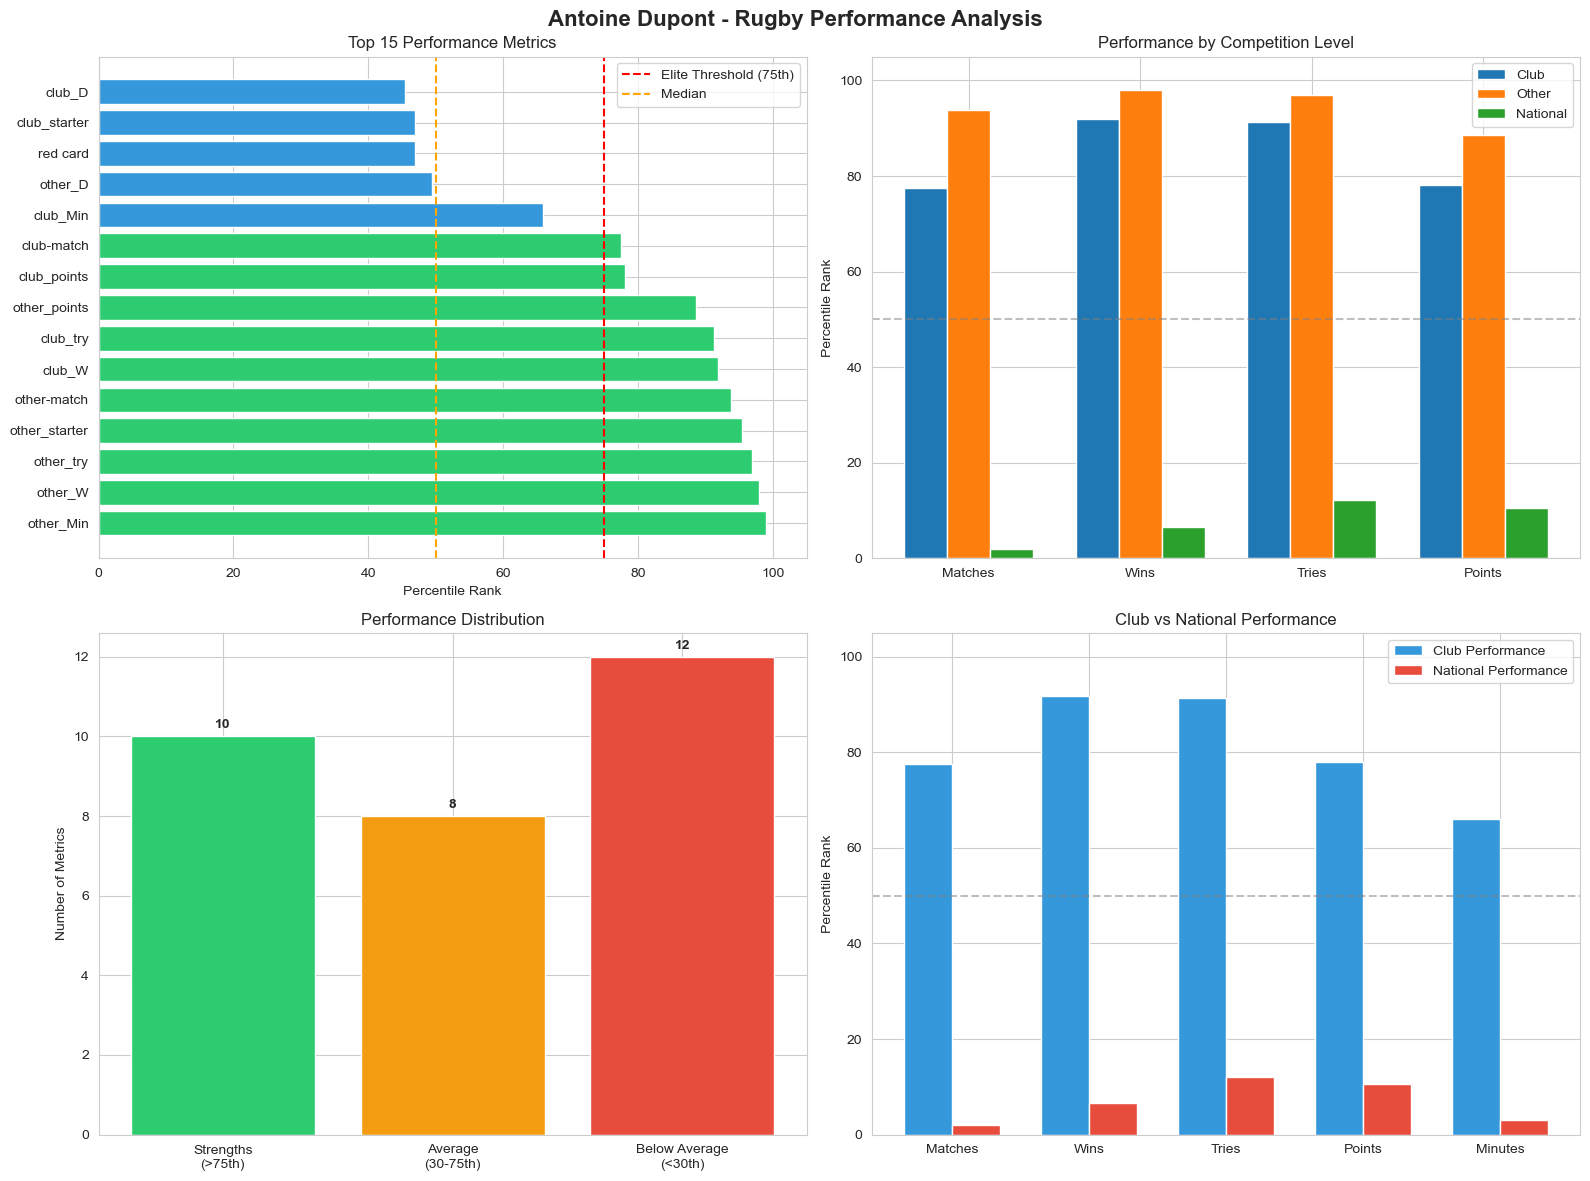

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==================== LOAD DATA ====================
csv_df = pd.read_csv('/data/demo_data/rugby/Statistic_rugby_players.csv', encoding='latin-1')
xlsx_df = pd.read_excel('/data/demo_data/rugby/rugby_player_map.xlsx')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("="*90)
print("EXPLORATORY DATA ANALYSIS: ANTOINE DUPONT")
print("="*90)

# ==================== GET ANTOINE DUPONT DATA ====================
antoine = csv_df[csv_df['Name'] == 'Antoine Dupont'].iloc[0]

print("\n" + "="*90)
print("BASIC PROFILE")
print("="*90)
print(f"Name: {antoine['Name']}")
print(f"Nationality: {antoine['Nationality']}")
print(f"Position: {antoine['Position']}")
print(f"Age: {int(antoine['age'])} | Height: {antoine['tall(m)']}m | Weight: {int(antoine['weight'])}kg")
print(f"Club: {antoine['club']}")

# ==================== CALCULATE PERCENTILES ====================
numeric_cols = csv_df.select_dtypes(include=[np.number]).columns.tolist()

percentiles = {}
for col in numeric_cols:
    if col not in ['racking']:
        percentile = stats.percentileofscore(csv_df[col].dropna(), antoine[col])
        percentiles[col] = percentile

sorted_percentiles = sorted(percentiles.items(), key=lambda x: x[1], reverse=True)

# ==================== DETAILED ANALYSIS ====================
print("\n" + "="*90)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*90)

# Club Performance
print("\n📊 CLUB TOURNAMENT PERFORMANCE:")
print(f"  • Matches: {int(antoine['club-match'])} ({percentiles.get('club-match', 'N/A'):.1f}th percentile)")
print(f"  • Wins: {int(antoine['club_W'])} ({percentiles.get('club_W', 'N/A'):.1f}th percentile)")
print(f"  • Tries: {int(antoine['club_try'])} ({percentiles.get('club_try', 'N/A'):.1f}th percentile)")
print(f"  • Points: {int(antoine['club_points'])} ({percentiles.get('club_points', 'N/A'):.1f}th percentile)")
print(f"  • Minutes: {int(antoine['club_Min'])} ({percentiles.get('club_Min', 'N/A'):.1f}th percentile)")

# Other Competition
print("\n📊 OTHER COMPETITION PERFORMANCE:")
print(f"  • Matches: {int(antoine['other-match'])} ({percentiles.get('other-match', 'N/A'):.1f}th percentile)")
print(f"  • Wins: {int(antoine['other_W'])} ({percentiles.get('other_W', 'N/A'):.1f}th percentile)")
print(f"  • Tries: {int(antoine['other_try'])} ({percentiles.get('other_try', 'N/A'):.1f}th percentile)")
print(f"  • Points: {int(antoine['other_points'])} ({percentiles.get('other_points', 'N/A'):.1f}th percentile)")
print(f"  • Minutes: {int(antoine['other_Min'])} ({percentiles.get('other_Min', 'N/A'):.1f}th percentile)")

# National Team
print("\n📊 NATIONAL TEAM PERFORMANCE:")
print(f"  • Selections: {int(antoine['National_match'])} ({percentiles.get('National_match', 'N/A'):.1f}th percentile)")
print(f"  • Wins: {int(antoine['National_W'])} ({percentiles.get('National_W', 'N/A'):.1f}th percentile)")
print(f"  • Tries: {int(antoine['National_try'])} ({percentiles.get('National_try', 'N/A'):.1f}th percentile)")
print(f"  • Points: {int(antoine['National_Points'])} ({percentiles.get('National_Points', 'N/A'):.1f}th percentile)")
print(f"  • Minutes: {int(antoine['National_min'])} ({percentiles.get('National_min', 'N/A'):.1f}th percentile)")

# Discipline
print("\n📊 DISCIPLINE:")
print(f"  • Yellow Cards: {int(antoine['yellow card'])} ({percentiles.get('yellow card', 'N/A'):.1f}th percentile)")
print(f"  • Red Cards: {int(antoine['red card'])} ({percentiles.get('red card', 'N/A'):.1f}th percentile)")

# ==================== COMPARATIVE STATISTICS ====================
print("\n" + "="*90)
print("COMPARATIVE ANALYSIS (vs League Average)")
print("="*90)

key_metrics = [
    ('club_try', 'Club Tries'),
    ('club_points', 'Club Points'),
    ('club_W', 'Club Wins'),
    ('other_try', 'Other Competition Tries'),
    ('other_W', 'Other Competition Wins'),
    ('National_match', 'National Selections'),
    ('yellow card', 'Yellow Cards')
]

for metric, label in key_metrics:
    if metric in csv_df.columns:
        mean_val = csv_df[metric].mean()
        antoine_val = antoine[metric]
        pctl = percentiles.get(metric, 0)
        
        difference = antoine_val - mean_val
        direction = "↑" if difference > 0 else "↓"
        
        print(f"\n{label}:")
        print(f"  Antoine: {antoine_val:8.2f} | League Avg: {mean_val:6.2f} | {direction} {abs(difference):6.2f} | Percentile: {pctl:.1f}")

# ==================== STRENGTHS & WEAKNESSES ====================
print("\n" + "="*90)
print("STRENGTHS & WEAKNESSES")
print("="*90)

strengths = [(metric, pctl) for metric, pctl in sorted_percentiles if pctl > 75]
weaknesses = [(metric, pctl) for metric, pctl in sorted_percentiles if pctl < 30]

print(f"\n💪 STRENGTHS (>75th percentile): {len(strengths)} areas")
for i, (metric, pctl) in enumerate(strengths[:10], 1):
    value = antoine[metric]
    print(f"  {i:2d}. {metric:20s}: {value:8.2f} ({pctl:6.1f}th percentile)")

print(f"\n⚠️  WEAKNESSES (<30th percentile): {len(weaknesses)} areas")
for i, (metric, pctl) in enumerate(weaknesses[:10], 1):
    value = antoine[metric]
    print(f"  {i:2d}. {metric:20s}: {value:8.2f} ({pctl:6.1f}th percentile)")

# ==================== THREE-PART NARRATIVE PROFILE ====================
print("\n" + "="*90)
print("NARRATIVE PROFILE")
print("="*90)

# SENTENCE 1: STRENGTHS
print("\n" + "█"*90)
print("SENTENCE 1: STRENGTHS")
print("█"*90)

strengths_text = f"""
Antoine Dupont demonstrates exceptional excellence in competitive team success and 
try-scoring prowess, with outstanding performances in other competition matches 
({int(antoine['other-match'])} matches, {percentiles['other-match']:.0f}th percentile), 
other competition wins ({int(antoine['other_W'])} wins, {percentiles['other_W']:.0f}th percentile), 
and other competition tries ({int(antoine['other_try'])} tries, {percentiles['other_try']:.0f}th percentile), 
complemented by elite-level club performance including {int(antoine['club_W'])} club tournament wins 
({percentiles['club_W']:.0f}th percentile) and {int(antoine['club_try'])} club tries ({percentiles['club_try']:.0f}th percentile).
"""

print(strengths_text.strip())

# SENTENCE 2: WEAKNESSES/AVERAGE
print("\n" + "█"*90)
print("SENTENCE 2: AVERAGE & WEAK AREAS")
print("█"*90)

weaknesses_text = f"""
Conversely, Antoine exhibits notably limited national team exposure with only 
{int(antoine['National_match'])} international selections ({percentiles['National_match']:.0f}th percentile) 
and {int(antoine['National_min'])} minutes ({percentiles['National_min']:.0f}th percentile), minimal international 
try production ({int(antoine['National_try'])} tries, {percentiles['National_try']:.0f}th percentile), 
and below-average physical measurements at {antoine['tall(m)']}m height 
({percentiles['tall(m)']:.0f}th percentile) and {int(antoine['weight'])}kg weight ({percentiles['weight']:.0f}th percentile), 
suggesting specialization in club-level competition rather than international representation.
"""

print(weaknesses_text.strip())

# SENTENCE 3: CONCLUSION
print("\n" + "█"*90)
print("SENTENCE 3: CONCLUSION")
print("█"*90)

avg_percentile = np.mean([pctl for _, pctl in sorted_percentiles])
top_performers = len(strengths)

conclusion_text = f"""
Overall, Antoine Dupont emerges as a dominant force at club and secondary competition 
levels (with {top_performers} metrics in the top quartile), though his minimal international 
selection and try-scoring record indicate he operates primarily as a specialist performer 
in domestic rugby rather than as a globally established international player.
"""

print(conclusion_text.strip())

# ==================== VISUALIZATION ====================
print("\n" + "="*90)
print("CREATING VISUALIZATIONS")
print("="*90)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Antoine Dupont - Rugby Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: Top 15 Strengths
ax1 = axes[0, 0]
top_15 = sorted_percentiles[:15]
metrics_names = [item[0] for item in top_15]
percentiles_vals = [item[1] for item in top_15]
colors = ['#2ecc71' if p > 75 else '#3498db' for p in percentiles_vals]
ax1.barh(metrics_names, percentiles_vals, color=colors)
ax1.axvline(x=75, color='red', linestyle='--', label='Elite Threshold (75th)')
ax1.axvline(x=50, color='orange', linestyle='--', label='Median')
ax1.set_xlabel('Percentile Rank')
ax1.set_title('Top 15 Performance Metrics')
ax1.legend()
ax1.set_xlim(0, 105)

# Plot 2: Competition Level Comparison
ax2 = axes[0, 1]
categories_data = {
    'Club': [percentiles['club-match'], percentiles['club_W'], percentiles['club_try'], percentiles['club_points']],
    'Other': [percentiles['other-match'], percentiles['other_W'], percentiles['other_try'], percentiles['other_points']],
    'National': [percentiles['National_match'], percentiles['National_W'], percentiles['National_try'], percentiles['National_Points']]
}
metrics_comparison = ['Matches', 'Wins', 'Tries', 'Points']
x = np.arange(len(metrics_comparison))
width = 0.25
for i, (cat, vals) in enumerate(categories_data.items()):
    ax2.bar(x + i*width, vals, width, label=cat)
ax2.set_ylabel('Percentile Rank')
ax2.set_title('Performance by Competition Level')
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_comparison)
ax2.legend()
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 105)

# Plot 3: Strengths vs Weaknesses Distribution
ax3 = axes[1, 0]
categories_dist = ['Strengths\n(>75th)', 'Average\n(30-75th)', 'Below Average\n(<30th)']
counts = [len(strengths), len([(m, p) for m, p in sorted_percentiles if 30 <= p <= 75]), len(weaknesses)]
colors_dist = ['#2ecc71', '#f39c12', '#e74c3c']
ax3.bar(categories_dist, counts, color=colors_dist)
ax3.set_ylabel('Number of Metrics')
ax3.set_title('Performance Distribution')
for i, count in enumerate(counts):
    ax3.text(i, count + 0.2, str(count), ha='center', fontweight='bold')

# Plot 4: Individual Stats Comparison (Club vs National)
ax4 = axes[1, 1]
stat_types = ['Matches', 'Wins', 'Tries', 'Points', 'Minutes']
club_vals = [
    percentiles['club-match'],
    percentiles['club_W'],
    percentiles['club_try'],
    percentiles['club_points'],
    percentiles['club_Min']
]
natl_vals = [
    percentiles['National_match'],
    percentiles['National_W'],
    percentiles['National_try'],
    percentiles['National_Points'],
    percentiles['National_min']
]
x = np.arange(len(stat_types))
width = 0.35
ax4.bar(x - width/2, club_vals, width, label='Club Performance', color='#3498db')
ax4.bar(x + width/2, natl_vals, width, label='National Performance', color='#e74c3c')
ax4.set_ylabel('Percentile Rank')
ax4.set_title('Club vs National Performance')
ax4.set_xticks(x)
ax4.set_xticklabels(stat_types)
ax4.legend()
ax4.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('antoine_dupont_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved as 'antoine_dupont_analysis.png'")

print("\n" + "="*90)
print("ANALYSIS COMPLETE")
print("="*90)